# Anàlisi estadística - BBF-14

Aquest notebook aprofundeix en l'anàlisi del target BBF-14, que amb 6 binders i 5 non-binders és el subconjunt més equilibrat del dataset de BindCraft. L'objectiu és identificar quines mètriques computacionals discriminen millor entre binders i non-binders per a aquest target, i construir un model de regressió logística que permeti avaluar la contribució conjunta de les mètriques.

In [1]:
import os
import pandas as pd
from pandas.api.types import is_numeric_dtype
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns
from scipy.stats import shapiro, ttest_ind, mannwhitneyu
from statsmodels.stats.multitest import multipletests
import statsmodels.api as sm
import math

OUTPUT_DIR = "/Users/bertaguiu/Desktop/github/bbf14/bindcraft_bbf14_outputs"
os.makedirs(OUTPUT_DIR, exist_ok=True)

df = pd.read_csv("/Users/bertaguiu/Desktop/github/bbf14/bindcraft_dataset.csv", sep=";", skiprows=2)

In [2]:
# Conversió numèrica i neteja ABANS de filtrar per target
df = df.apply(pd.to_numeric, errors="ignore")
df["Affinity_nM"] = pd.to_numeric(
    df["Affinity_nM"].str.replace("*", "", regex=False),
    errors="coerce"
)
numeric_like = df.columns[df.dtypes == "object"]
print("Columnes no numèriques:", numeric_like.tolist())

Columnes no numèriques: ['Target', 'DesignName', 'Trajectory', 'Sequence', 'Average_InterfaceAAs', '1_InterfaceAAs', '2_InterfaceAAs']


In [3]:
# Filtrar BBF-14 i eliminar files sense Binding
df_bbf14 = df[df["Target"] == "BBF-14"].copy()
df_bbf14 = df_bbf14[df_bbf14["Binding"].notna()]
df_bbf14.head()

,Target,DesignName,Trajectory,Binding,Affinity_nM,Length,Sequence,MPNN_score,MPNN_seq_recovery,Average_pLDDT,...,2_Binder_pAE,3_Binder_pAE,4_Binder_pAE,5_Binder_pAE,Average_Binder_RMSD,1_Binder_RMSD,2_Binder_RMSD,3_Binder_RMSD,4_Binder_RMSD,5_Binder_RMSD
0,BBF-14,BBF_b10,BBF-14_l85_s43382_mpnn1,0.0,NaN,85,MIPDDIKLTLYLINGNEVPEKVEIDPKGLSKEELKEAVKEPFEKAK...,0.74,0.46,0.93,...,0.11,NaN,NaN,NaN,1.06,1.05,1.06,NaN,NaN,NaN
1,BBF-14,BBF_b11,BBF-14_l117_s79064_mpnn2,0.0,NaN,117,MEELKKLLEEYLKHIEWPKIVFEEIWPTLDSIEGKVKLFEWFYDNI...,1.04,0.27,0.91,...,0.13,NaN,NaN,NaN,1.68,1.61,1.75,NaN,NaN,NaN
2,BBF-14,BBF_b13,BBF-14_l102_s87116_mpnn12,0.0,NaN,102,PARPEPEELWYKFKGKGPVVFVRVNGVLHVFKDDGNNMVSVLSAKP...,0.98,0.35,0.88,...,0.17,NaN,NaN,NaN,1.66,1.80,1.51,NaN,NaN,NaN
3,BBF-14,BBF_b5,BBF-14_l145_s38796_mpnn9,0.0,NaN,145,LYEEFKKLYEEFLRIGMEAMIKLQEGYASGDREDEELHEEIVKLLK...,0.93,0.39,0.95,...,0.07,NaN,NaN,NaN,0.90,0.93,0.86,NaN,NaN,NaN
4,BBF-14,BBF_b7,BBF-14_l157_s19126_mpnn17,0.0,NaN,157,SHMDYLLNWAEWQVRQLVGFLFWLFAEAGYEVIITEDTVERTETSV...,1.02,0.31,0.85,...,0.18,NaN,NaN,NaN,1.66,1.57,1.74,NaN,NaN,NaN


## Swarm plot

Es representa la distribució dels valors de cada mètrica sense normalitzar, separant binders i non-binders per color. La visualització permet identificar patrons visuals de separació entre els dos grups i avaluar quines mètriques podrien ser millors predictors de l'activitat de binding.

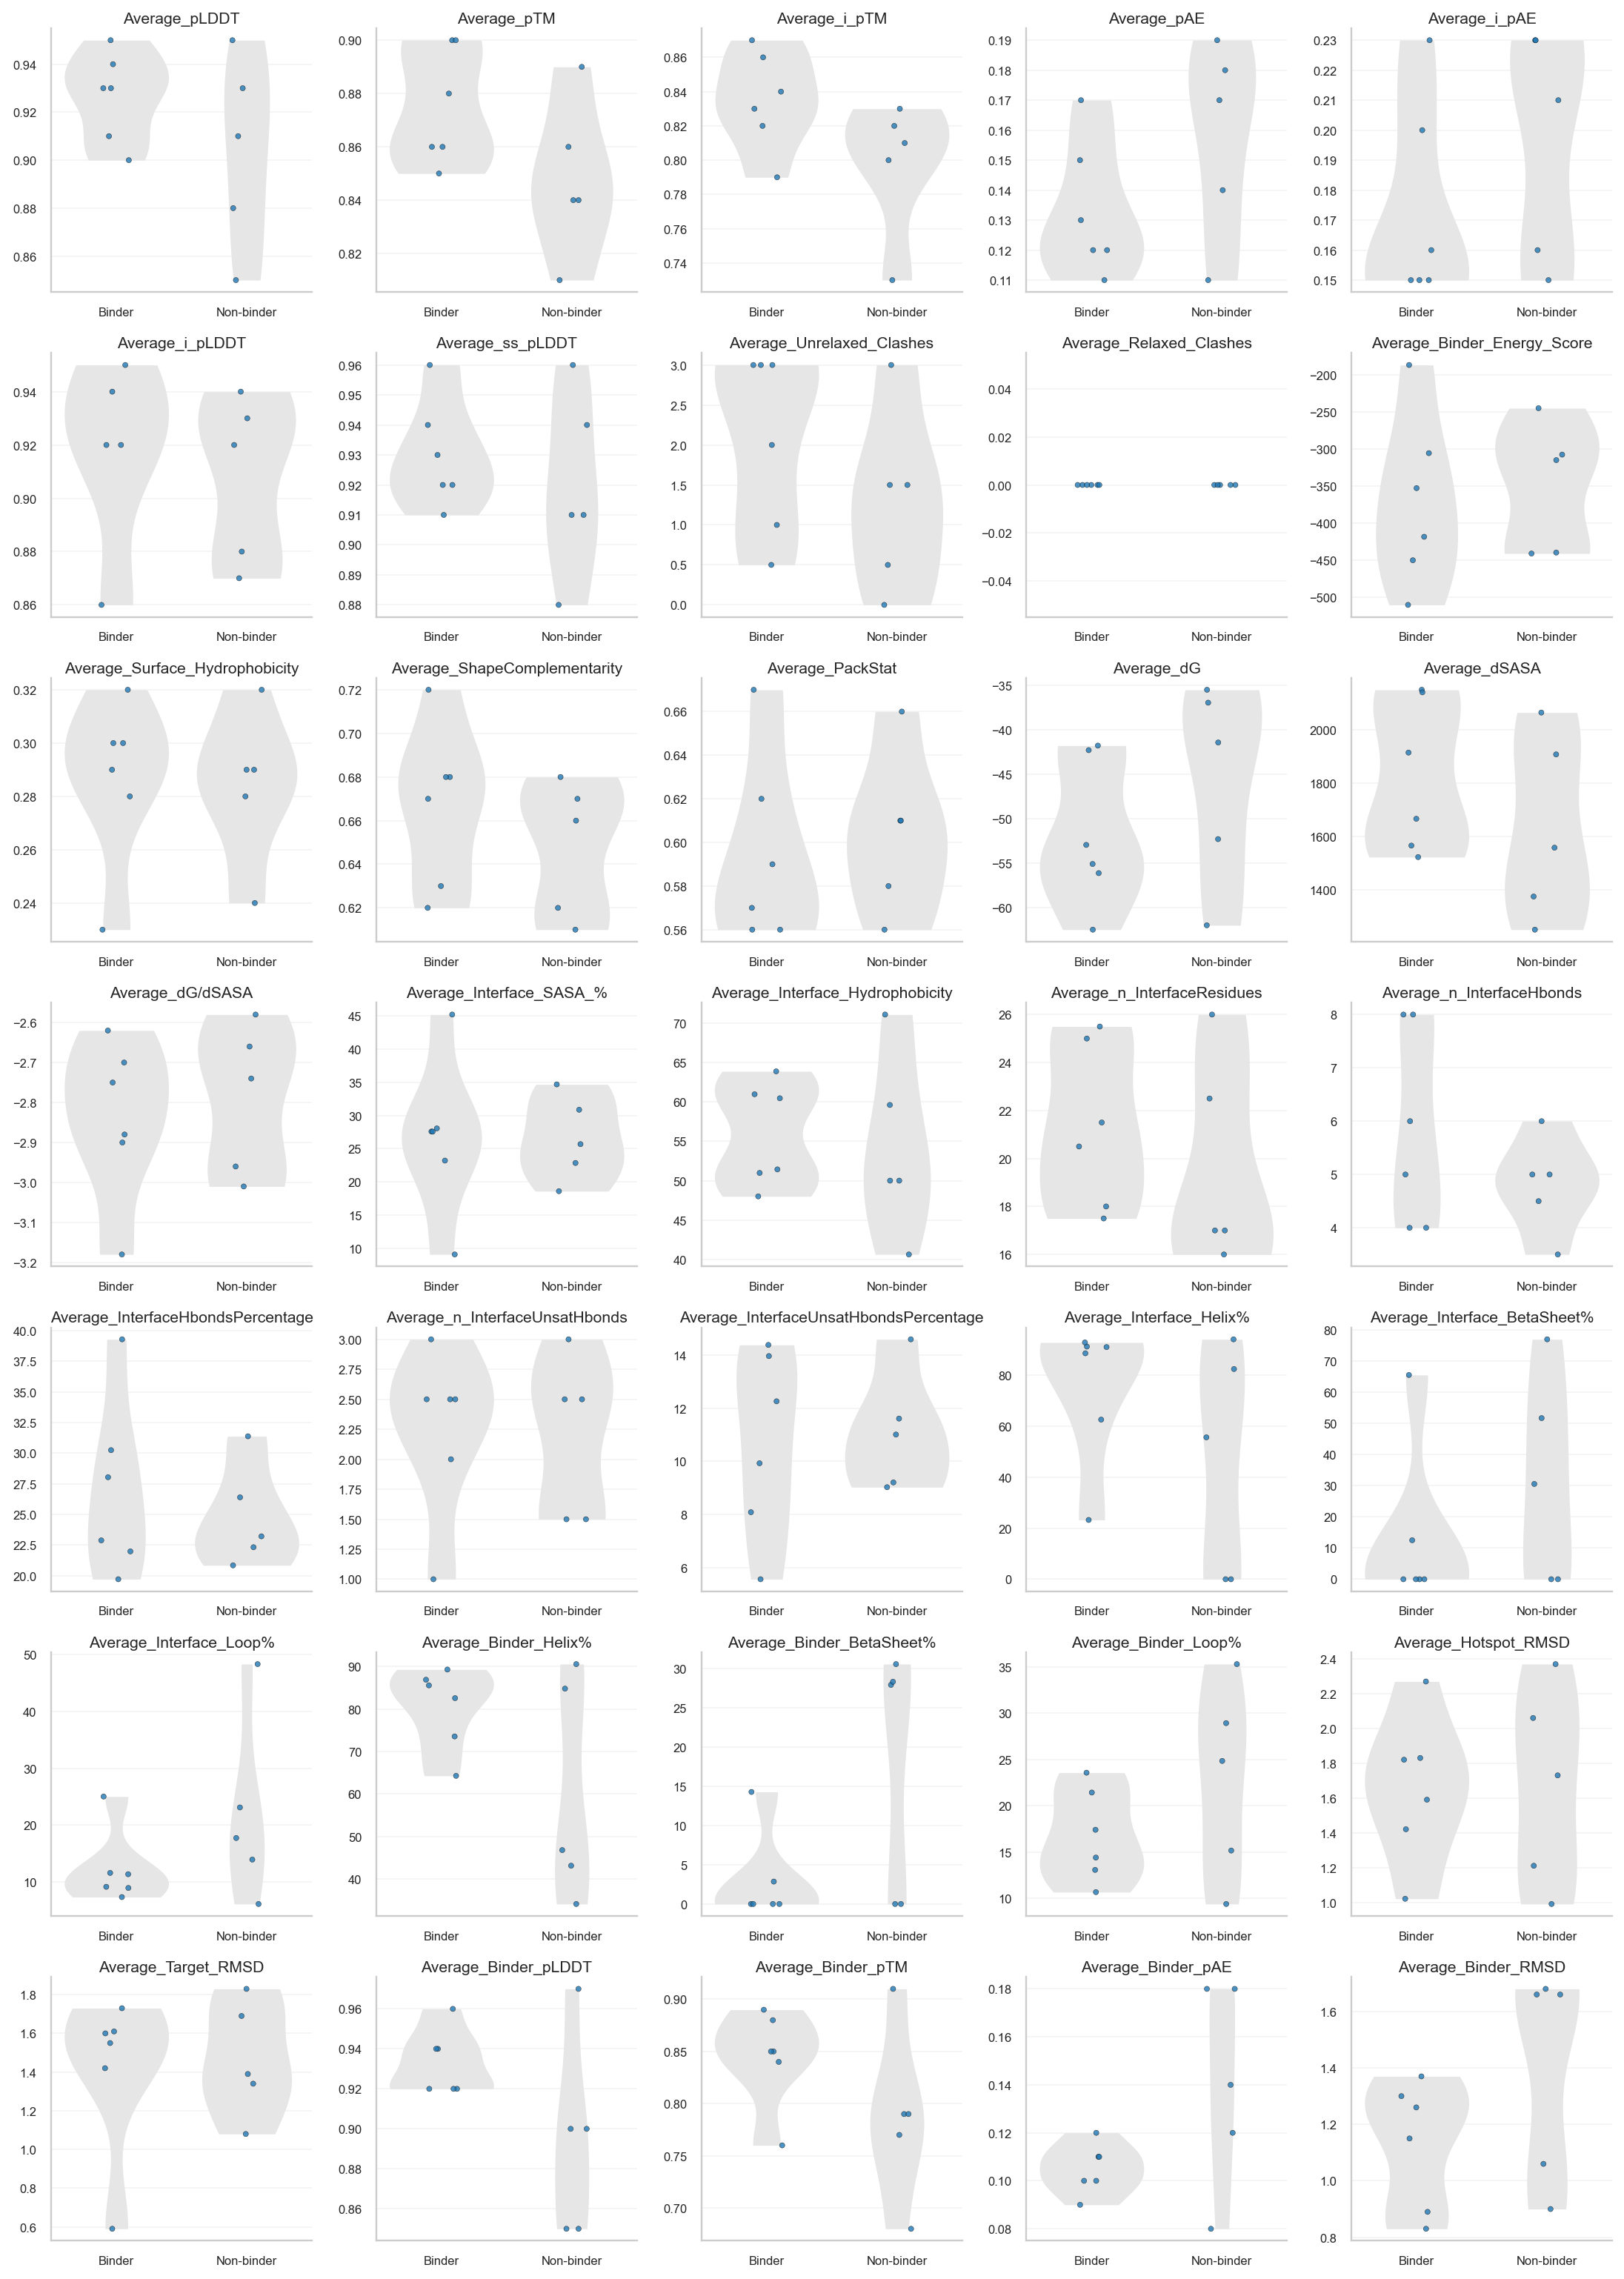

In [4]:
sns.set_theme(style="whitegrid", context="paper")

target_sel = "BBF-14"
BIND_ORDER = ["Binder", "Non-binder"]

metrics = [c for c in df_bbf14.columns if "Average" in c and is_numeric_dtype(df_bbf14[c])]

long = df_bbf14[["Target", "Binding"] + metrics].melt(
    id_vars=["Target", "Binding"],
    value_vars=metrics,
    var_name="Metric",
    value_name="Value"
).dropna(subset=["Value"])

long["Binding"] = long["Binding"].astype(int).map({1: "Binder", 0: "Non-binder"})
long["Binding"] = pd.Categorical(long["Binding"], categories=BIND_ORDER, ordered=True)

palette = {target_sel: sns.color_palette("tab20", n_colors=1)[0]}

def _iqr_filter_by_group(d, group_col="Binding", value_col="Value", k=1.5):
    parts = []
    for g, sub in d.groupby(group_col, dropna=False):
        q1 = sub[value_col].quantile(0.25)
        q3 = sub[value_col].quantile(0.75)
        iqr = q3 - q1
        if pd.isna(iqr):
            parts.append(sub)
            continue
        if iqr == 0:
            parts.append(sub[sub[value_col] <= q3])
            continue
        lo = q1 - k * iqr
        hi = q3 + k * iqr
        parts.append(sub[(sub[value_col] >= lo) & (sub[value_col] <= hi)])
    return pd.concat(parts, axis=0)

ncols = 5
nplots = len(metrics)
nrows = math.ceil(nplots / ncols)

fig, axes = plt.subplots(nrows=nrows, ncols=ncols, figsize=(2.6 * ncols, 2.6 * nrows), dpi=170)
axes = np.array(axes).reshape(-1)

for i, m in enumerate(metrics):
    ax = axes[i]
    d = long[long["Metric"] == m].copy()

    if m in {"Average_ss_pLDDT", "Average_i_pLDDT"}:
        d = d[(d["Value"] >= 0) & (d["Value"] <= 1)]
    if m == "Average_i_pLDDT":
        d = _iqr_filter_by_group(d, group_col="Binding", value_col="Value", k=1.5)
    if m in {"Average_Relaxed_Clashes", "Average_Unrelaxed_Clashes"}:
        d = d[d["Value"] >= 0]
        d = _iqr_filter_by_group(d, group_col="Binding", value_col="Value", k=1.5)

    sns.violinplot(data=d, x="Binding", y="Value", order=BIND_ORDER, inner="quartile",
                   cut=0, linewidth=0, color="0.90", bw_adjust=0.8, gridsize=200, ax=ax)
    sns.stripplot(data=d, x="Binding", y="Value", order=BIND_ORDER, hue="Target",
                  hue_order=[target_sel], palette=palette, jitter=0.12, size=3.0,
                  alpha=0.80, linewidth=0.2, edgecolor="black", ax=ax)

    ax.set_title(m, fontsize=9, pad=3)
    ax.set_xlabel("")
    ax.set_ylabel("")
    ax.tick_params(axis="both", labelsize=7)
    ax.grid(axis="y", alpha=0.20)
    ax.grid(axis="x", visible=False)
    sns.despine(ax=ax)
    if ax.legend_ is not None:
        ax.legend_.remove()

for j in range(nplots, len(axes)):
    fig.delaxes(axes[j])

fig.subplots_adjust(hspace=0.40, wspace=0.30)
plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, "swarm_plot_bbf14.png"), bbox_inches="tight", dpi=150)
plt.show()

In [5]:
import pandas as pd

def keep_only_average_metrics(
    df,
    keep_cols=None,
    label_col="Binding",
    keyword="Average",
    verbose=True
):
    """
    Conserva:
    - columnes identificadores importants (keep_cols)
    - la columna label_col
    - només les columnes numèriques que contenen 'Average' al nom
    """

    df = df.copy()

    if keep_cols is None:
        keep_cols = [
            "Target",
            "DesignName",
            "Trajectory",
            "Affinity_nM",
            "Sequence",
            "Average_InterfaceAAs",
            "1_InterfaceAAs",
            "2_InterfaceAAs"
        ]

    cols_to_keep = [c for c in keep_cols if c in df.columns]
    if label_col in df.columns:
        cols_to_keep.append(label_col)

    average_numeric_cols = [
        c for c in df.columns
        if (
            pd.api.types.is_numeric_dtype(df[c])
            and keyword in c
            and c != label_col
        )
    ]

    final_cols = cols_to_keep + [c for c in average_numeric_cols if c not in cols_to_keep]
    df_filtered = df[final_cols].copy()

    if verbose:
        print("=== FILTRAT DE COLUMNES ===")
        print(f"Columnes totals inicials: {df.shape[1]}")
        print(f"Columnes finals: {df_filtered.shape[1]}")
        print(f"Mètriques numèriques amb '{keyword}': {len(average_numeric_cols)}")
        print("\nMètriques seleccionades:")
        print(average_numeric_cols)

    return df_filtered, average_numeric_cols

In [6]:
import numpy as np
from sklearn.preprocessing import StandardScaler
from sklearn.impute import SimpleImputer

def normalize_metrics(
    df,
    feature_cols,
    label_col="Binding",
    nan_strategy="median",
    verbose=True
):
    """
    Normalitza només les feature_cols.
    Gestiona NaNs amb:
    - 'drop'
    - 'median'
    """

    df = df.copy()

    missing_features = [c for c in feature_cols if c not in df.columns]
    if missing_features:
        raise ValueError(f"Falten aquestes features al dataframe: {missing_features}")

    if label_col not in df.columns:
        raise ValueError(f"No existeix la columna '{label_col}' al dataframe.")

    nan_counts = df[feature_cols].isna().sum()
    nan_counts = nan_counts[nan_counts > 0].sort_values(ascending=False)

    if verbose:
        print("\n=== NORMALITZACIÓ ===")
        print(f"Files inicials: {len(df)}")
        if len(nan_counts) > 0:
            print("Columnes amb NaNs:")
            print(nan_counts)
        else:
            print("No hi ha NaNs a les features seleccionades.")

    imputer = None

    if nan_strategy == "drop":
        before = len(df)
        df = df.dropna(subset=feature_cols + [label_col]).copy()
        after = len(df)

        if verbose:
            print(f"\nEstratègia NaN: DROP")
            print(f"Files eliminades: {before - after}")
            print(f"Files finals: {after}")

    elif nan_strategy == "median":
        before = len(df)
        df = df.dropna(subset=[label_col]).copy()
        after = len(df)

        imputer = SimpleImputer(strategy="median")
        df[feature_cols] = imputer.fit_transform(df[feature_cols])

        if verbose:
            print(f"\nEstratègia NaN: MEDIAN")
            print(f"Files eliminades per label NaN: {before - after}")
            print(f"Files finals: {after}")

    else:
        raise ValueError("nan_strategy ha de ser 'drop' o 'median'.")

    scaler = StandardScaler()
    df[feature_cols] = scaler.fit_transform(df[feature_cols])

    if verbose:
        print("Normalització completada.")

    return df, scaler, imputer

In [7]:
def logistic_regression_visual(
    df,
    label_col="Binding",
    design_col="DesignName",
    target_col="Target",
    max_iter=3000,
    verbose=True,
    output_dir=None
):
    import numpy as np
    import pandas as pd
    import matplotlib.pyplot as plt
    import seaborn as sns

    from sklearn.model_selection import LeaveOneOut
    from sklearn.linear_model import LogisticRegression
    from sklearn.metrics import (
        confusion_matrix,
        ConfusionMatrixDisplay,
        roc_curve,
        roc_auc_score,
        classification_report,
        accuracy_score,
        precision_score,
        recall_score,
        f1_score
    )

    df = df.copy()

    # Mètriques seleccionades
    selected_features = [
        "Average_pLDDT",
        "Average_ss_pLDDT",
        "Average_i_pTM",
        "Average_pTM",
        "Average_ShapeComplementarity",
        "Average_dG",
        "Average_dSASA",
        "Average_Interface_Hydrophobicity",
        "Average_n_InterfaceHbonds"
    ]

    # Només les que existeixen al dataframe
    feature_cols = [c for c in selected_features if c in df.columns]

    if len(feature_cols) == 0:
        raise ValueError("Cap de les mètriques seleccionades existeix al dataframe.")

    if label_col not in df.columns:
        raise ValueError(f"No existeix la columna '{label_col}' al dataframe.")

    # Eliminar files amb NaN a features o label
    df = df.dropna(subset=feature_cols + [label_col]).copy()

    X = df[feature_cols]
    y = df[label_col].astype(int)

    if len(y.unique()) < 2:
        raise ValueError("La regressió logística necessita dues classes.")

    if verbose:
        print("\n=== MÈTRIQUES UTILITZADES EN LA REGRESSIÓ ===")
        for f in feature_cols:
            print(f)

        print("\n=== DISTRIBUCIÓ DE CLASSES ===")
        print(y.value_counts().sort_index())

        print("\n=== VALIDACIÓ ===")
        print("S'utilitza Leave-One-Out Cross Validation (LOOCV).")

    loo = LeaveOneOut()

    y_true_all = []
    y_pred_all = []
    y_proba_all = []
    test_indices = []
    coef_list = []

    for train_idx, test_idx in loo.split(X):
        X_train, X_test = X.iloc[train_idx], X.iloc[test_idx]
        y_train, y_test = y.iloc[train_idx], y.iloc[test_idx]

        if len(np.unique(y_train)) < 2:
            continue

        model = LogisticRegression(max_iter=max_iter)
        model.fit(X_train, y_train)

        y_pred = model.predict(X_test)[0]
        y_proba = model.predict_proba(X_test)[0, 1]

        y_true_all.append(y_test.iloc[0])
        y_pred_all.append(y_pred)
        y_proba_all.append(y_proba)
        test_indices.append(X_test.index[0])
        coef_list.append(model.coef_[0])

    y_true_all = np.array(y_true_all)
    y_pred_all = np.array(y_pred_all)
    y_proba_all = np.array(y_proba_all)

    if len(y_true_all) == 0:
        raise ValueError("No s'han pogut generar prediccions LOOCV.")

    acc = accuracy_score(y_true_all, y_pred_all)
    prec = precision_score(y_true_all, y_pred_all, zero_division=0)
    rec = recall_score(y_true_all, y_pred_all, zero_division=0)
    f1 = f1_score(y_true_all, y_pred_all, zero_division=0)

    if len(np.unique(y_true_all)) == 2:
        auc = roc_auc_score(y_true_all, y_proba_all)
        fpr, tpr, _ = roc_curve(y_true_all, y_proba_all)
    else:
        auc = np.nan
        fpr, tpr = None, None

    if verbose:
        print("\n=== RESULTATS GLOBALS LOOCV ===")
        print(f"Accuracy : {acc:.3f}")
        print(f"Precision: {prec:.3f}")
        print(f"Recall   : {rec:.3f}")
        print(f"F1-score : {f1:.3f}")
        if np.isnan(auc):
            print("AUC      : no es pot calcular")
        else:
            print(f"AUC      : {auc:.3f}")
        print("\n=== CLASSIFICATION REPORT ===")
        print(classification_report(y_true_all, y_pred_all, zero_division=0))

    coef_array = np.array(coef_list)
    coef_mean = coef_array.mean(axis=0)
    coef_std = coef_array.std(axis=0)

    coef_df = pd.DataFrame({
        "Metric": feature_cols,
        "Coefficient_mean": coef_mean,
        "Coefficient_std": coef_std,
        "AbsCoefficient_mean": np.abs(coef_mean)
    }).sort_values("Coefficient_mean").reset_index(drop=True)

    pred_cols = []
    if target_col in df.columns:
        pred_cols.append(target_col)
    if design_col in df.columns:
        pred_cols.append(design_col)

    pred_df = df.loc[test_indices, pred_cols + [label_col]].copy()
    pred_df["PredictedClass"] = y_pred_all
    pred_df["PredictedProbability_Binder"] = y_proba_all
    pred_df["CorrectPrediction"] = pred_df[label_col].values == pred_df["PredictedClass"].values
    pred_df = pred_df.sort_values("PredictedProbability_Binder", ascending=False).reset_index(drop=True)

    cm = confusion_matrix(y_true_all, y_pred_all)

    fig, axes = plt.subplots(2, 2, figsize=(15, 11))
    axes = axes.flatten()

    sns.barplot(data=coef_df, x="Coefficient_mean", y="Metric", ax=axes[0])
    axes[0].axvline(0, linestyle="--", linewidth=1, color="black")
    axes[0].set_title("Coeficients mitjans de la regressió logística (LOOCV)")
    axes[0].set_xlabel("Coeficient mitjà")
    axes[0].set_ylabel("Mètrica")

    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=["Non-binder", "Binder"])
    disp.plot(ax=axes[1], colorbar=False)
    axes[1].set_title("Confusion matrix global (LOOCV)")

    if fpr is not None and tpr is not None:
        axes[2].plot(fpr, tpr, label=f"AUC = {auc:.3f}")
        axes[2].plot([0, 1], [0, 1], linestyle="--", color="gray")
        axes[2].set_title("ROC curve global (LOOCV)")
        axes[2].set_xlabel("False Positive Rate")
        axes[2].set_ylabel("True Positive Rate")
        axes[2].legend()
    else:
        axes[2].text(0.5, 0.5, "ROC no disponible", ha="center", va="center")
        axes[2].set_title("ROC curve global (LOOCV)")
        axes[2].set_xticks([])
        axes[2].set_yticks([])

    bins = np.linspace(0, 1, 12)
    axes[3].hist(y_proba_all[y_true_all == 0], bins=bins, alpha=0.7, label="Non-binder")
    axes[3].hist(y_proba_all[y_true_all == 1], bins=bins, alpha=0.7, label="Binder")
    axes[3].axvline(0.5, linestyle="--", linewidth=1, color="black")
    axes[3].set_title("Probabilitat predita de binding (LOOCV)")
    axes[3].set_xlabel("P(Binder)")
    axes[3].set_ylabel("Nombre de mostres")
    axes[3].legend()

    plt.tight_layout()
    if output_dir:
        import os
        plt.savefig(os.path.join(output_dir, "logistic_regression_bbf14.png"), bbox_inches="tight", dpi=150)
    plt.show()

    return {
        "feature_cols": feature_cols,
        "coefficients": coef_df,
        "predictions": pred_df,
        "accuracy": acc,
        "precision": prec,
        "recall": rec,
        "f1": f1,
        "auc": auc,
        "confusion_matrix": cm,
        "y_true": y_true_all,
        "y_pred": y_pred_all,
        "y_proba": y_proba_all
    }

=== FILTRAT DE COLUMNES ===
Columnes totals inicials: 225
Columnes finals: 44
Mètriques numèriques amb 'Average': 35

Mètriques seleccionades:
['Average_pLDDT', 'Average_pTM', 'Average_i_pTM', 'Average_pAE', 'Average_i_pAE', 'Average_i_pLDDT', 'Average_ss_pLDDT', 'Average_Unrelaxed_Clashes', 'Average_Relaxed_Clashes', 'Average_Binder_Energy_Score', 'Average_Surface_Hydrophobicity', 'Average_ShapeComplementarity', 'Average_PackStat', 'Average_dG', 'Average_dSASA', 'Average_dG/dSASA', 'Average_Interface_SASA_%', 'Average_Interface_Hydrophobicity', 'Average_n_InterfaceResidues', 'Average_n_InterfaceHbonds', 'Average_InterfaceHbondsPercentage', 'Average_n_InterfaceUnsatHbonds', 'Average_InterfaceUnsatHbondsPercentage', 'Average_Interface_Helix%', 'Average_Interface_BetaSheet%', 'Average_Interface_Loop%', 'Average_Binder_Helix%', 'Average_Binder_BetaSheet%', 'Average_Binder_Loop%', 'Average_Hotspot_RMSD', 'Average_Target_RMSD', 'Average_Binder_pLDDT', 'Average_Binder_pTM', 'Average_Binder_p

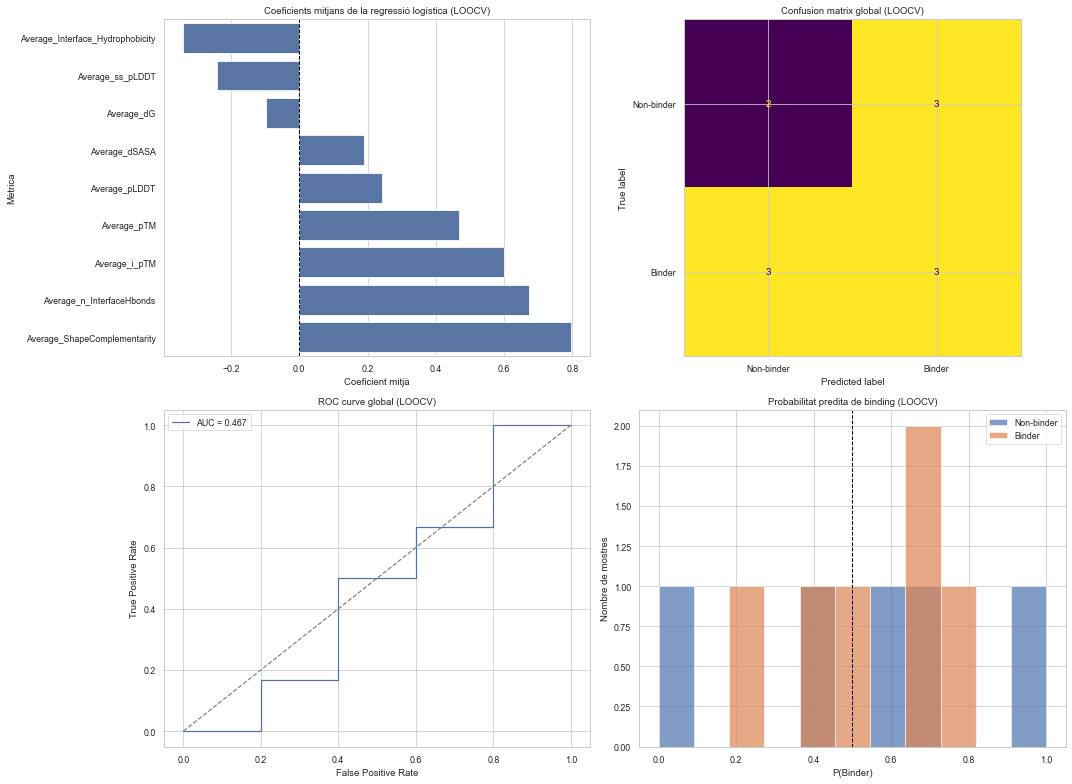

In [8]:
# 1. Quedar-nos només amb mètriques numèriques que continguin "Average"
df_avg, avg_features = keep_only_average_metrics(df_bbf14)

# 2. Normalitzar només aquestes mètriques
df_avg_norm, scaler, imputer = normalize_metrics(
    df_avg,
    feature_cols=avg_features,
    nan_strategy="median"
)

# 3. Fer la regressió logística i desar el plot
results = logistic_regression_visual(
    df_avg_norm,
    output_dir=OUTPUT_DIR
)